# DATA 606 Capstone Deliverable: Machine Learning

**Author:** Brett Allen (ballen3@umbc.edu)

**Topic:** Air Traffic Controller (ATC) Communications Intelligence

*Speech Recognition and Information Extraction for Aviation Safety*

## Table of Contents

- [Setup](#setup)
  - [Imports](#imports)
  - [Configuration](#configuration)
  - [Hardware / Software Constraints](#hardware--software-constraints)
- [A. Load and Prepare Data](#a-load-and-prepare-data)
  - [Outlier Exclusion](#outlier-exclusion)
  - [Transcript Normalization for Scoring](#transcript-normalization-for-scoring)
- [B. Baseline ASR (openai/whisper-medium.en)](#b-baseline-asr-openaiwhisper-mediumen)
- [C. Model Comparison (jacktol/whisper-medium.en-fine-tuned-for-ATC)](#c-model-comparison-jacktolwhisper-mediumen-fine-tuned-for-atc)
  - [Fine-Tuning](#fine-tuning)
  - [Evaluate the Fine-Tuned Model](#evaluate-the-fine-tuned-model)
- [D. Aviation-Specific Evaluation](#d-aviation-specific-evaluation)
  - [Altitude / Heading / Runway / Frequency Accuracy](#altitude--heading--runway--frequency-accuracy)
  - [WER vs. Utterance Characteristics](#wer-vs-utterance-characteristics)
  - [Does Lower WER Mean Better Aviation-Entity Recognition?](#does-lower-wer-mean-better-aviation-entity-recognition)
- [Error Taxonomy](#error-taxonomy)
- [Summary](#summary)

## Setup

In [1]:
!python --version

Python 3.12.4


In [2]:
!cat ../requirements.txt

# Python 3.12.x
datasets==3.2.0
transformers==4.57.6
librosa==1.0.0
soundfile==0.14.0
coverage>=7.7.0  # numba's coverage integration needs coverage.types.Tracer (added in 7.7.0)
pandas==2.3.3
numpy==2.5.3
matplotlib==3.10.6
seaborn==0.13.2
scipy==1.18.1
wordcloud==1.9.4
torch==2.5.1  # NOTE: a plain install from this file pulls the CPU/default-CUDA-tag wheel;
              # this environment uses the +cu124 build (`pip install torch==2.5.1 --index-url
              # https://download.pytorch.org/whl/cu124`), which PyPI's default index won't reproduce.
accelerate==1.15.0  # must stay new enough for transformers==4.57.6's Trainer (older accelerate
                    # lacks Accelerator.unwrap_model's `keep_torch_compile` kwarg it now passes)
jiwer==3.1.0



In [3]:
!python -m pip install -q -r ../requirements.txt

### Imports

In [4]:
%load_ext autoreload
%autoreload 2

import os

# This notebook only uses the PyTorch backend. Without this, `transformers`
# auto-probes for TensorFlow/Flax on import; in this shared environment that
# probe hits an installed TensorFlow build incompatible with a newer
# protobuf, raising (caught, non-fatal, but noisy) AttributeErrors.
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"

import re
import sys
import json

import numpy as np
import pandas as pd
import torch
import jiwer
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import disable_progress_bars
from transformers import WhisperProcessor, WhisperForConditionalGeneration, Seq2SeqTrainer, Seq2SeqTrainingArguments

# Make the reusable pipeline code in ../src importable from the notebook
sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from preprocessing import DataIngestPipeline
from preprocessing.text_features import normalize_transcript
from preprocessing.vocab import (
    ATC_COMMAND_VERBS,
    ATC_NUMERAL_WORDS,
    ICAO_PHONETIC_ALPHABET,
    KNOWN_CALLSIGN_WORDS,
)

### Configuration

In [5]:
RANDOM_SEED = 42

FIGURES_DIR = os.path.join(os.getcwd(), "..", "res", "figures")

HUE_ORDER = ["atc-asr-dataset", "atcosim"]
PALETTE = {"atc-asr-dataset": "#2a78d6", "atcosim": "#eb6834"}

RESULTS_DIR = os.path.join(os.getcwd(), "..", "data", "processed", "asr_results")

# Scale toggle: a small stratified subset while prototyping/debugging this
# notebook; set to None to scale up to the full ~1,909-row held-out test set
# once the harness below is trusted.
N_EVAL_SAMPLES = 100

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASELINE_MODEL_ID = "openai/whisper-medium.en"
COMPARISON_MODEL_ID = "jacktol/whisper-medium.en-fine-tuned-for-ATC"

In [6]:
disable_progress_bars()  # keep re-runs free of noisy download/map/cast tqdm output

%matplotlib inline
sns.set_theme(style="whitegrid")

# Reused from notebooks/comprehensive_eda.ipynb for consistent figures/colors across notebooks.
os.makedirs(FIGURES_DIR, exist_ok=True)

# Per-row ASR outputs and experiment-results tables are saved here so results
# survive outside transient notebook output (data/processed/ is gitignored,
# same convention as utterances.parquet / combined_dataset/).
os.makedirs(RESULTS_DIR, exist_ok=True)

In [7]:
def save_fig(fig, name, dpi=150):
    """Save a matplotlib figure to res/figures/<name>.png for reuse in slides."""
    path = os.path.join(FIGURES_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {os.path.relpath(path, os.getcwd())}")
    return path

### Hardware / Software Constraints
Inspect current device specs for reference prior to model loading and training.

In [8]:
import accelerate
import transformers
from importlib.metadata import version as pkg_version

print(f"Python / platform : {sys.version.splitlines()[0]}")
print(f"torch             : {torch.__version__} (CUDA build: {torch.version.cuda})")
print(f"CUDA available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU               : {props.name} ({props.total_memory / 1e9:.1f} GB VRAM)")
print(f"transformers      : {transformers.__version__}")
print(f"accelerate        : {accelerate.__version__}")
print(f"jiwer             : {pkg_version('jiwer')}")
print(f"device selected   : {DEVICE}")

Python / platform : 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:12:24) [GCC 11.2.0]
torch             : 2.5.1+cu124 (CUDA build: 12.4)
CUDA available    : True
GPU               : NVIDIA GeForce RTX 3070 Ti Laptop GPU (8.6 GB VRAM)
transformers      : 4.57.6
accelerate        : 1.15.0
jiwer             : 3.1.0
device selected   : cuda


## A. Load and Prepare Data

### Evaluation Subset Selection

> **NOTE:** The evaluation subset that will be used for ASR modeling is produced via `DataIngestPipeline`. We'll need to take it a step further by applying a stratified sub-sample for fast iteration purposes. This will be a configurable process so that we can easily scale against the full test set later with no other code changes.

### Leakage Prevention (Already Handled Upstream)

> **NOTE:** Speaker/session-level leakage prevention is handled by `DataIngestPipeline` as well. We discovered there were duplictes between the original ATCO2-ASR dataset and the new ATC-ASR dataset which led to the decision of dropping the original dataset to prevent the duplicate records appearing in train and test (e.g., leakage).

In [9]:
data_dir = "../data/"
pipeline = DataIngestPipeline(data_dir=data_dir)
combined_dataset, utterance_df = pipeline.run()  # reuses the cached corpus; no recompute here

test_df = utterance_df[utterance_df["dataset_split"] == "test"].reset_index(drop=True)
print(f"Test split: {len(test_df)} rows")
test_df["dataset_source"].value_counts()

Test split: 1909 rows


dataset_source
atcosim            1096
atc-asr-dataset     813
Name: count, dtype: int64

### Outlier Exclusion

> **NOTE:** There was one major outlier from the ATCOSIM dataset which ended up being a 38.9 seconds clip of a personal conversation that didn't adhere to the standard ATC phraseology. We retained this outlier as part of the combined/processed corpus during comprehensive EDA but flagged it as a candidate to exclude for ASR training and evaluation since we don't want the ASR model to learn this type of language

In [10]:
outlier_candidates = test_df[(test_df["dataset_source"] == "atcosim") & (test_df["duration_sec"] > 30)]
display(outlier_candidates[["utterance_id", "duration_sec", "transcript"]])

excluded_ids = set(outlier_candidates["utterance_id"])
test_df_eval_pool = test_df[~test_df["utterance_id"].isin(excluded_ids)].reset_index(drop=True)
print(f"Excluded {len(excluded_ids)} off-domain outlier row(s) from the eval pool: {sorted(excluded_ids)}")
print(f"Eval pool size after exclusion: {len(test_df_eval_pool)}")

,utterance_id,duration_sec,transcript


Excluded 0 off-domain outlier row(s) from the eval pool: []
Eval pool size after exclusion: 1909


In [11]:
def build_eval_subset(pool_df: pd.DataFrame, n=N_EVAL_SAMPLES, seed=RANDOM_SEED) -> pd.DataFrame:
    """Stratified sample by `dataset_source`, proportional to `pool_df`'s own
    source composition. `n=None` returns the full pool unchanged."""
    if n is None:
        return pool_df.reset_index(drop=True)
    frac = n / len(pool_df)
    parts = [
        g.sample(n=max(1, round(len(g) * frac)), random_state=seed)
        for _, g in pool_df.groupby("dataset_source")
    ]
    return pd.concat(parts, ignore_index=True)

In [12]:
eval_df = build_eval_subset(test_df_eval_pool, n=N_EVAL_SAMPLES, seed=RANDOM_SEED)
print(f"Eval subset size: {len(eval_df)}")
eval_df["dataset_source"].value_counts()

Eval subset size: 100


dataset_source
atcosim            57
atc-asr-dataset    43
Name: count, dtype: int64

In [13]:
def attach_audio(eval_df: pd.DataFrame, combined_dataset, split="test"):
    """Return a HF `Dataset` of decoded-audio rows in the same order as
    `eval_df`, joined by `utterance_id` -- never by position, since
    `combined_dataset[split]`'s row order has no guaranteed relationship to
    `eval_df`'s (which came from a separate sample/filter on `utterance_df`)."""
    id_to_idx = {uid: i for i, uid in enumerate(combined_dataset[split]["utterance_id"])}
    indices = [id_to_idx[uid] for uid in eval_df["utterance_id"]]
    return combined_dataset[split].select(indices)

In [14]:
eval_audio = attach_audio(eval_df, combined_dataset, split="test")
assert list(eval_audio["utterance_id"]) == list(eval_df["utterance_id"])
print(f"Audio attached for {len(eval_audio)} utterances.")

Audio attached for 100 utterances.


### Transcript Normalization for Scoring

> **NOTE:** Whisper decodes numbers as digits so if an ATCO utters, "descend to six zero zero zero feet", Whisper will decode it as, "descend to 6000 feet". We need to address this edge case to prevent skewing the word error rate (WER) evaluation since this wouldn't be considered a "real" recognition error.

In [15]:
_DIGIT_WORDS = {
    "0": "zero", "1": "one", "2": "two", "3": "three", "4": "four",
    "5": "five", "6": "six", "7": "seven", "8": "eight", "9": "nine",
}
_NUMERIC_RUN_RE = re.compile(r"\d+(?:[.\-]\d+)*")


def expand_digits_to_atc_words(text: str) -> str:
    """Expand every digit run in `text` into individual spoken digit words,
    matching ATC phraseology (digit-by-digit, never grouped: '660' ->
    'six six zero', NOT 'six hundred sixty'). '.' -> 'decimal', '-' ->
    'dash'. No-op on text with no digits (idempotent on reference text,
    which is already spelled out)."""
    def _expand(match: re.Match) -> str:
        run = match.group(0)
        words = []
        for ch in run:
            if ch == ".":
                words.append("decimal")
            elif ch == "-":
                words.append("dash")
            else:
                words.append(_DIGIT_WORDS[ch])
        return " ".join(words)

    return _NUMERIC_RUN_RE.sub(_expand, text)


def normalize_for_scoring(text: str) -> str:
    """Scoring-only normalization: digit-word expansion, then the existing
    casing/punctuation/whitespace normalization
    (`preprocessing.text_features.normalize_transcript`). Never mutates the
    raw stored hypothesis -- computed at scoring time only."""
    return normalize_transcript(expand_digits_to_atc_words(text or ""))

In [16]:
# Sanity-check the normalizer against hand-picked Whisper-style digit output
# before trusting it downstream -- cheap, catches bugs early.
_NORMALIZER_TEST_CASES = [
    ("contact approach on 133.4", "contact approach on one three three decimal four"),
    ("descend to 6000 feet", "descend to six zero zero zero feet"),
    ("runway 27-left cleared to land", "runway two seven left cleared to land"),
    ("squawk 0472", "squawk zero four seven two"),
    ("active between 1200-1400", "active between one two zero zero dash one four zero zero"),
    ("N123AB", "n one two three a b"),
]
for raw, expected in _NORMALIZER_TEST_CASES:
    got = normalize_for_scoring(raw)
    status = "OK " if got == expected else "MISMATCH"
    print(f"{status} | {raw!r} -> {got!r}")

OK  | 'contact approach on 133.4' -> 'contact approach on one three three decimal four'
OK  | 'descend to 6000 feet' -> 'descend to six zero zero zero feet'
OK  | 'runway 27-left cleared to land' -> 'runway two seven left cleared to land'
OK  | 'squawk 0472' -> 'squawk zero four seven two'
OK  | 'active between 1200-1400' -> 'active between one two zero zero dash one four zero zero'
MISMATCH | 'N123AB' -> 'none two threeab'


**Observation:** This rule-based (regex) approach does not handle edge cases such as call sign expansion. We'll have to defer to aviation information extraction (e.g., NER for callsign extraction) later on.

## B. Baseline ASR (`openai/whisper-medium.en`)
Using a generic, English-only Whisper checkpoint with no ATC-specific training. We're trying to see how well a base model will do without any training (e.g,. zero-shot) and record it as a basis of comparison for a trained model.

In [17]:
# `.en` checkpoints are English-only, so no `language=`/`task=` generate
# kwargs are needed (they're for the multilingual Whisper variants).
baseline_dtype = torch.float16 if DEVICE == "cuda" else torch.float32
baseline_processor = WhisperProcessor.from_pretrained(BASELINE_MODEL_ID)
baseline_model = WhisperForConditionalGeneration.from_pretrained(
    BASELINE_MODEL_ID, dtype=baseline_dtype
).to(DEVICE)
baseline_model.eval()
print(f"Loaded {BASELINE_MODEL_ID} on {DEVICE} ({baseline_dtype}).")

Loaded openai/whisper-medium.en on cuda (torch.float16).


In [18]:
def transcribe_batch(model, processor, audio_arrays, batch_size=8, device=DEVICE):
    """Run Whisper generation over a list of 1-D numpy waveforms (16kHz
    mono).

    Whisper's feature extractor always pads/truncates every clip to a fixed
    30-second window internally, so each item produces a same-shaped log-mel
    spectrogram regardless of `duration_sec` (no manual padding or
    attention-mask handling is needed).

    Returns a list of raw (unnormalized) hypothesis strings, in input order.
    """
    hypotheses = []
    for start in range(0, len(audio_arrays), batch_size):
        chunk = audio_arrays[start:start + batch_size]
        inputs = processor(chunk, sampling_rate=16_000, return_tensors="pt")
        input_features = inputs.input_features.to(device=device, dtype=model.dtype)
        with torch.no_grad():
            generated_ids = model.generate(input_features)
        hypotheses.extend(processor.batch_decode(generated_ids, skip_special_tokens=True))
    return hypotheses

In [19]:
audio_arrays = [row["array"] for row in eval_audio["audio"]]
baseline_hyps_raw = transcribe_batch(baseline_model, baseline_processor, audio_arrays, batch_size=8)

baseline_results = pd.DataFrame({
    "utterance_id": eval_df["utterance_id"],
    "dataset_source": eval_df["dataset_source"],
    "reference": eval_df["transcript"],
    "hypothesis": baseline_hyps_raw,  # raw, unnormalized (preserved for inspection)
    "model_version": BASELINE_MODEL_ID,
})
baseline_results.head()

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


,utterance_id,dataset_source,reference,hypothesis,model_version
0,atc-asr-dataset-test-000247,atc-asr-dataset,LUFTHANSA SEVEN CORRECTION ONE KILO KILO DESCE...,"Bongos 7, correction, 1 kilo kilo, descent fl...",openai/whisper-medium.en
1,atc-asr-dataset-test-000589,atc-asr-dataset,THAI NINER TWO ONE PRAHA,"Hi, 902, Vanu Praha.",openai/whisper-medium.en
2,atc-asr-dataset-test-000227,atc-asr-dataset,CSA ONE NINER SIX TWO LINE UP RUNWAY THREE ONE,Say save on the 962 lineup and wait till then.,openai/whisper-medium.en
3,atc-asr-dataset-test-000291,atc-asr-dataset,ZULU BRAVO DELTA HOLDING POINT ONE THREE CALL YOU,"NABL, I'll leave blind, one area clear",openai/whisper-medium.en
4,atc-asr-dataset-test-000539,atc-asr-dataset,RUSSIA TWO TWO ONE TOWER GOOD MORNING CONTINUE...,"Russia to do one tower good morning, continue...",openai/whisper-medium.en


In [20]:
baseline_out_path = os.path.join(RESULTS_DIR, "baseline_whisper_medium_en.csv")
baseline_results.to_csv(baseline_out_path, index=False)
print(f"Saved: {os.path.relpath(baseline_out_path)}")

Saved: ../data/processed/asr_results/baseline_whisper_medium_en.csv


In [21]:
def score_wer_cer(results_df: pd.DataFrame) -> pd.DataFrame:
    """Add `reference_norm`, `hypothesis_norm`, `wer`, `cer` columns,
    applying `normalize_for_scoring` to both sides at scoring time only."""
    out = results_df.copy()
    out["reference_norm"] = out["reference"].map(normalize_for_scoring)
    out["hypothesis_norm"] = out["hypothesis"].map(normalize_for_scoring)
    out["wer"] = [jiwer.wer(r, h) for r, h in zip(out["reference_norm"], out["hypothesis_norm"])]
    out["cer"] = [jiwer.cer(r, h) for r, h in zip(out["reference_norm"], out["hypothesis_norm"])]
    return out


baseline_scored = score_wer_cer(baseline_results)

# Corpus-level WER/CER via jiwer on the full string lists 
# This is the correct aggregate (edit-distance-weighted), not a mean of WERs, which
# would double-count noise from short utterances.
overall_wer = jiwer.wer(list(baseline_scored["reference_norm"]), list(baseline_scored["hypothesis_norm"]))
overall_cer = jiwer.cer(list(baseline_scored["reference_norm"]), list(baseline_scored["hypothesis_norm"]))
print(f"Baseline overall WER: {overall_wer:.3f} | CER: {overall_cer:.3f}")

Baseline overall WER: 0.838 | CER: 0.589


> **NOTE:** real (atc-asr-dataset) and simulated (atcosim) audio occupy measurably different acoustic distributions. Aggregating WER across sources would hide this domain gap, so it's always reported separately as well as in aggregate.

In [22]:
baseline_scored.groupby("dataset_source").apply(
    lambda g: jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])), include_groups=False
).rename("wer")

dataset_source
atc-asr-dataset    1.618844
atcosim            0.219015
Name: wer, dtype: float64

**Observation:** As expected, there's a considerably higher WER in the real ATC-ASR dataset compared to the simulated ATCOSIM dataset, most likely due to the varying acoustics.

In [23]:
# Inspect the best, median, and worst WER examples to get a feel for the model's behavior on this domain.
display_cols = ["utterance_id", "dataset_source", "reference", "hypothesis", "wer", "cer"]
baseline_scored_sorted = baseline_scored.sort_values("wer").reset_index(drop=True)

print("Correct / near-correct examples (lowest WER):")
display(baseline_scored_sorted[display_cols].head(5))

mid = len(baseline_scored_sorted) // 2
print("Typical-error examples (median band):")
display(baseline_scored_sorted[display_cols].iloc[mid - 2: mid + 3])

print("Worst-error examples (highest WER):")
display(baseline_scored_sorted[display_cols].tail(5))

Correct / near-correct examples (lowest WER):


,utterance_id,dataset_source,reference,hypothesis,wer,cer
0,atc-asr-dataset-test-000328,atc-asr-dataset,SEVEN,7,0.0,0.0
1,atcosim-train-002832,atcosim,affirm,Affirm,0.0,0.0
2,atcosim-train-005386,atcosim,jetcom one three three climb to flight level t...,Jetcom 133 climb to flight level 340.,0.0,0.0
3,atc-asr-dataset-test-000063,atc-asr-dataset,APPROVED,Approved.,0.0,0.0
4,atcosim-train-000727,atcosim,swissair seven eight three romeo rhein identif...,"Swissair 783, Romeo Rhein identified.",0.0,0.0


Typical-error examples (median band):


,utterance_id,dataset_source,reference,hypothesis,wer,cer
48,atcosim-train-007140,atcosim,alitalia four zero four rhein one three two de...,Alitalia 404913 to decimal 4.,0.272727,0.163934
49,atcosim-train-003653,atcosim,alitalia two nine one direct to trasadingen,Alitalia 2901 direct to Trasadengen.,0.285714,0.139535
50,atc-asr-dataset-test-000357,atc-asr-dataset,CSA SEVEN SIX ECHO TURN RIGHT PROCEED DIRECT T...,"CSA 7C, contact right, proceed direct to Agav...",0.294118,0.142857
51,atcosim-train-000671,atcosim,lufthansa four six five two rhein radar identi...,"Lufthansa 4652, Ryan radar identified, climb ...",0.294118,0.160377
52,atcosim-train-005451,atcosim,iberia three four two two good morning maintai...,"Liberia 342, good morning, maintain 340, trus...",0.307692,0.135802


Worst-error examples (highest WER):


,utterance_id,dataset_source,reference,hypothesis,wer,cer
95,atc-asr-dataset-test-000453,atc-asr-dataset,INBOUND TUSIN,"Thank you, Patricia.",1.500000,1.000000
96,atc-asr-dataset-test-000659,atc-asr-dataset,CSA TWO EIGHT SEVEN PRAHA RADAR RADAR CONTACT ...,"If you have any questions, please contact the...",1.571429,1.162500
97,atc-asr-dataset-test-000067,atc-asr-dataset,STANDBY,And bye,2.000000,0.571429
98,atc-asr-dataset-test-000352,atc-asr-dataset,QUALITY NINER ONE ROMEO RUNWAY ONE THREE CLEAR...,"COTY 9-1, N.R.R.R.R.R.R.R.R.R.R.R.R.R.R.R.R.R...",13.117647,4.673913
99,atc-asr-dataset-test-000294,atc-asr-dataset,TOWER GOOD MORNING QUALITY FOUR ZERO EIGHT NIN...,"Good morning, good morning, good morning, goo...",19.333333,20.593407


In [24]:
# Take a look at utterance `atc-asr-dataset-test-000659` to verify that it isn't an invalid transcript (reference value).
edge_case_id = 'atc-asr-dataset-test-000659'
edge_case = baseline_scored_sorted[baseline_scored_sorted['utterance_id'] == edge_case_id]
print(f'Reference  : {edge_case["reference"].iloc[0]}')
print(f'Hypothesis : {edge_case["hypothesis"].iloc[0]}')

Reference  : CSA TWO EIGHT SEVEN PRAHA RADAR RADAR CONTACT DESCEND FLIGHT LEVEL ONE ZERO ZERO
Hypothesis :  If you have any questions, please contact the flight control team at 1-800-566-7200.


In [25]:
# Now let's obtain the original evaluation record containing the actual audio data for the edge case utterance
edge_case_idx = list(eval_audio["utterance_id"]).index(edge_case_id)
eval_audio[edge_case_idx]

{'audio': {'path': None,
  'array': array([ 0.00061035,  0.00085449,  0.00057983, ...,  0.00778198,
         -0.00033569, -0.00378418], shape=(60000,)),
  'sampling_rate': 16000},
 'text': 'CSA TWO EIGHT SEVEN PRAHA RADAR RADAR CONTACT DESCEND FLIGHT LEVEL ONE ZERO ZERO',
 'dataset_source': 'atc-asr-dataset',
 'original_split': 'test',
 'utterance_id': 'atc-asr-dataset-test-000659',
 'id': 'SD4XT823TVKVM53M21VW',
 'audio_path': 'SD4XT823TVKVM53M21VW.wav',
 'duration_sec': 3.75,
 'sample_rate': 16000,
 'word_count': 14,
 'character_count': 80,
 'speech_rate_wpm': 224.0,
 'recorded_at': None,
 'audio_decode_error': None,
 'audio_checksum': 'bf611d6557db936b4ca9c8c852548b6804508530',
 'rms_energy': 0.043821100145578384,
 'silence_pct': 7.8400000000000025,
 'snr_db_proxy': 24.05265998840332,
 'zero_crossing_rate': 0.10428528866525423,
 'spectral_centroid_hz': 1218.0612417745258,
 'spectral_bandwidth_hz': 1038.7940031415517,
 'transcript_normalized': 'csa two eight seven praha radar radar c

In [26]:
# Render audio player to listen to it ourselves and verify the audio content compared to the reference transcript
from IPython.display import Audio

edge_case_audio = eval_audio[edge_case_idx]["audio"]
Audio(data=edge_case_audio["array"], rate=edge_case_audio["sampling_rate"])

**Observation:** After listening to the actual audio, it does in fact reflect the `reference` field value, `"CSA TWO EIGHT SEVEN PRAHA RADAR RADAR CONTACT DESCEND FLIGHT LEVEL ONE ZERO ZERO"`. However, the audio quality (acoustics) is very poor so it makes more sense that the base whisper model classified this case as, `"If you have any questions, please contact the flight control team at 1-800-566-7200."`.

## C. Model Comparison (`jacktol/whisper-medium.en-fine-tuned-for-ATC`)
Using a Whisper medium.en checkpoint fine-tuned on the same `jacktol/ATC-ASR-Dataset` we're using as part of our combined dataset.

> **NOTE:** It's possible that this fine-tuned model was trained on a train/test overlap which is a risk for leakage.

Two ~medium-sized Whisper checkpoints in fp16 (~1.5GB weights each) fit comfortably alongside each other in 8GB VRAM. If VRAM availability becomes an issue, free it first:

```python
del baseline_model; torch.cuda.empty_cache()
```

In [27]:
print(f"Comparison Model: {COMPARISON_MODEL_ID}")

Comparison Model: jacktol/whisper-medium.en-fine-tuned-for-ATC


In [28]:
comparison_dtype = torch.float16 if DEVICE == "cuda" else torch.float32
comparison_processor = WhisperProcessor.from_pretrained(COMPARISON_MODEL_ID)
comparison_model = WhisperForConditionalGeneration.from_pretrained(
    COMPARISON_MODEL_ID, dtype=comparison_dtype
).to(DEVICE)
comparison_model.eval()
print(f"Loaded {COMPARISON_MODEL_ID} on {DEVICE} ({comparison_dtype}).")

Loaded jacktol/whisper-medium.en-fine-tuned-for-ATC on cuda (torch.float16).


In [29]:
# Same eval_audio/eval_df records, same transcribe_batch function -- the two
# conditions differ only in which model/processor is passed in.
comparison_hyps_raw = transcribe_batch(comparison_model, comparison_processor, audio_arrays, batch_size=8)

comparison_results = pd.DataFrame({
    "utterance_id": eval_df["utterance_id"],
    "dataset_source": eval_df["dataset_source"],
    "reference": eval_df["transcript"],
    "hypothesis": comparison_hyps_raw,
    "model_version": COMPARISON_MODEL_ID,
})
comparison_out_path = os.path.join(RESULTS_DIR, "comparison_whisper_medium_en_atc.csv")
comparison_results.to_csv(comparison_out_path, index=False)
print(f"Saved: {os.path.relpath(comparison_out_path)}")

comparison_scored = score_wer_cer(comparison_results)
comparison_overall_wer = jiwer.wer(list(comparison_scored["reference_norm"]), list(comparison_scored["hypothesis_norm"]))
comparison_overall_cer = jiwer.cer(list(comparison_scored["reference_norm"]), list(comparison_scored["hypothesis_norm"]))
print(f"Comparison overall WER: {comparison_overall_wer:.3f} | CER: {comparison_overall_cer:.3f}")

Saved: ../data/processed/asr_results/comparison_whisper_medium_en_atc.csv
Comparison overall WER: 0.113 | CER: 0.059


In [30]:
comparison_wer_by_source = comparison_scored.groupby("dataset_source").apply(
    lambda g: jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])), include_groups=False
).rename("wer")

comparison_wer_by_source

dataset_source
atc-asr-dataset    0.092077
atcosim            0.129032
Name: wer, dtype: float64

In [31]:
# Create a summary table of WER/CER by model version and dataset source
combined_results = pd.concat([baseline_scored, comparison_scored], ignore_index=True)
combined_summary = (
    combined_results.groupby(["model_version", "dataset_source"])
    .apply(lambda g: pd.Series({
        "n": len(g),
        "wer": jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])),
        "cer": jiwer.cer(list(g["reference_norm"]), list(g["hypothesis_norm"])),
    }), include_groups=False)
    .reset_index()
)

combined_results.to_csv(os.path.join(RESULTS_DIR, "combined_asr_results.csv"), index=False)
combined_summary.to_csv(os.path.join(RESULTS_DIR, "combined_asr_summary.csv"), index=False)
combined_summary

,model_version,dataset_source,n,wer,cer
0,jacktol/whisper-medium.en-fine-tuned-for-ATC,atc-asr-dataset,43.0,0.092077,0.038153
1,jacktol/whisper-medium.en-fine-tuned-for-ATC,atcosim,57.0,0.129032,0.075588
2,openai/whisper-medium.en,atc-asr-dataset,43.0,1.618844,1.199542
3,openai/whisper-medium.en,atcosim,57.0,0.219015,0.117647


### Fine-Tuning
Goal is to fine-tune a base whisper model and attempt to achieve similar/same performance as the fine-tuned medium whisper model by `jacktol`, using the custom train/test split created by the data ingest pipeline. The dataset curated in this project prevents data leakage so there's much less likelihood of overfitting.

**Target model**: `openai/whisper-small.en`. Full fine-tuning keeps fp32 master weights (for `fp16=True` mixed-precision training) plus Adam's two fp32 moment buffers plus fp32 gradients. For medium.en (769M params) it's roughly 4 x 769M x 4 bytes = ~12.3GB just for weights + gradients + optimizer state, before any activations. `whisper-small.en` (244M params) needs roughly a quarter of that and fits comfortably with a standard setup (e.g., 8GB VRAM).

**Train subset**: a small stratified sample (`N_TRAIN_SAMPLES`) from the the full ~13,956 samples train split. This validates the whole training setup (e.g., data prep, collator, metrics, checkpointing) end-to-end quickly; the same `build_eval_subset` helper from Section A does the stratified sampling.

In [32]:
# See the markdown above for why this differs from BASELINE_MODEL_ID/COMPARISON_MODEL_ID.
FINETUNE_MODEL_ID = "openai/whisper-small.en"

# Same N_EVAL_SAMPLES-style scale toggle, applied to the train/validation
# subsets used for this fine-tuning run.
N_TRAIN_SAMPLES = 1000
N_FINETUNE_VAL_SAMPLES = 200  # keep per-epoch validation fast too

print(f"Fine-tune target : {FINETUNE_MODEL_ID}")
print(f"Train subset size: {N_TRAIN_SAMPLES}")
print(f"Val subset size  : {N_FINETUNE_VAL_SAMPLES}")

Fine-tune target : openai/whisper-small.en
Train subset size: 1000
Val subset size  : 200


In [33]:
train_pool_df = utterance_df[utterance_df["dataset_split"] == "train"].reset_index(drop=True)
val_pool_df = utterance_df[utterance_df["dataset_split"] == "validation"].reset_index(drop=True)

train_subset_df = build_eval_subset(train_pool_df, n=N_TRAIN_SAMPLES, seed=RANDOM_SEED)
val_subset_df = build_eval_subset(val_pool_df, n=N_FINETUNE_VAL_SAMPLES, seed=RANDOM_SEED)

train_audio_subset = attach_audio(train_subset_df, combined_dataset, split="train")
val_audio_subset = attach_audio(val_subset_df, combined_dataset, split="validation")

print(f"Fine-tuning train subset: {len(train_audio_subset)} rows")
print(train_subset_df["dataset_source"].value_counts())
print(f"\nFine-tuning validation subset: {len(val_audio_subset)} rows")
print(val_subset_df["dataset_source"].value_counts())

Fine-tuning train subset: 1000 rows
dataset_source
atcosim            534
atc-asr-dataset    466
Name: count, dtype: int64

Fine-tuning validation subset: 200 rows
dataset_source
atcosim            111
atc-asr-dataset     89
Name: count, dtype: int64


In [34]:
finetune_processor = WhisperProcessor.from_pretrained(FINETUNE_MODEL_ID)

def prepare_example(example):
    """Convert one raw {audio, text, ...} row into the {input_features,
    labels} shape Seq2SeqTrainer expects: a fixed-size log-mel spectrogram
    and tokenized label ids. Dropped columns (audio, text, dataset_source,
    ...) aren't needed once this runs -- see the `.map(remove_columns=...)`
    calls below."""
    audio = example["audio"]
    example["input_features"] = finetune_processor.feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"]
    ).input_features[0]
    example["labels"] = finetune_processor.tokenizer(example["text"]).input_ids
    return example


train_dataset = train_audio_subset.map(
    prepare_example, remove_columns=train_audio_subset.column_names
)
val_dataset = val_audio_subset.map(
    prepare_example, remove_columns=val_audio_subset.column_names
)
print(f"Prepared {len(train_dataset)} train / {len(val_dataset)} validation examples.")

Prepared 1000 train / 200 validation examples.


In [35]:
from dataclasses import dataclass
from typing import Dict, List, Union

# Free the inference-only models from Sections B/C before training, to
# maximize VRAM headroom for the fine-tuning run -- neither is referenced
# again after this point in the notebook.
del baseline_model, comparison_model
if DEVICE == "cuda":
    torch.cuda.empty_cache()

# A fresh fp32 copy for training. baseline_model above was loaded in fp16
# for inference only; training on top of already-fp16 weights risks
# gradient underflow/instability. Seq2SeqTrainingArguments(fp16=True)
# below handles mixed-precision training internally from these fp32
# master weights, the standard pattern. No gradient checkpointing needed --
# whisper-small.en's full fine-tuning memory footprint (fp32 weights +
# gradients + Adam moments, ~4GB) already fits comfortably in 8GB VRAM,
# and gradient checkpointing here conflicts with Seq2SeqTrainer's
# generation-based eval step in this transformers version (a known
# incompatibility, not worth chasing when it isn't needed anyway).
finetune_model = WhisperForConditionalGeneration.from_pretrained(FINETUNE_MODEL_ID).to(DEVICE)


@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    """Pads a batch's variable-length label sequences and stacks the
    already-fixed-size (30s-window) input_features; replaces label padding
    with -100 so the loss ignores it, and drops the collator-supplied BOS
    token from labels since the model's own decoder_start_token_id already
    provides it. The standard Whisper fine-tuning collator."""

    processor: WhisperProcessor
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


finetune_data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=finetune_processor,
    decoder_start_token_id=finetune_model.config.decoder_start_token_id,
)


def compute_metrics(pred):
    """WER on the validation subset during training, using the same
    normalize_for_scoring pipeline as Sections B/C so numbers are
    comparable across all three conditions."""
    pred_ids = pred.predictions
    label_ids = pred.label_ids.copy()
    label_ids[label_ids == -100] = finetune_processor.tokenizer.pad_token_id

    pred_str = finetune_processor.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = finetune_processor.batch_decode(label_ids, skip_special_tokens=True)

    pred_norm = [normalize_for_scoring(p) for p in pred_str]
    label_norm = [normalize_for_scoring(l) for l in label_str]
    return {"wer": jiwer.wer(label_norm, pred_norm)}

In [36]:
finetune_model_safe_id = FINETUNE_MODEL_ID.split('/')[-1].replace('.', '-')

FINE_TUNE_HYPERPARAMS = {
    "output_dir": f"../models/{finetune_model_safe_id}-atc-finetuned",
    "logging_dir": f"../res/logs/{finetune_model_safe_id}-atc-finetuned",
    "learning_rate": 1e-5,    
    "per_device_train_batch_size": 4,
    "per_device_eval_batch_size": 4,
    "gradient_accumulation_steps": 8,
    "num_train_epochs": 3,
    "fp16": DEVICE == "cuda",
    "eval_strategy": "epoch",
    "save_strategy": "epoch",
    "save_total_limit": 2,
    "load_best_model_at_end": True,
    "metric_for_best_model": "wer",
    "greater_is_better": False,
    "predict_with_generate": True,
    "generation_max_length": 225,
    "report_to": [],
    "seed": RANDOM_SEED,
}
print(json.dumps(FINE_TUNE_HYPERPARAMS, indent=2))

{
  "output_dir": "../models/whisper-small-en-atc-finetuned",
  "logging_dir": "../res/logs/whisper-small-en-atc-finetuned",
  "learning_rate": 1e-05,
  "per_device_train_batch_size": 4,
  "per_device_eval_batch_size": 4,
  "gradient_accumulation_steps": 8,
  "num_train_epochs": 3,
  "fp16": true,
  "eval_strategy": "epoch",
  "save_strategy": "epoch",
  "save_total_limit": 2,
  "load_best_model_at_end": true,
  "metric_for_best_model": "wer",
  "greater_is_better": false,
  "predict_with_generate": true,
  "generation_max_length": 225,
  "report_to": [],
  "seed": 42
}


In [37]:
training_args = Seq2SeqTrainingArguments(**FINE_TUNE_HYPERPARAMS)
trainer = Seq2SeqTrainer(
    model=finetune_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,          # never combined_dataset["test"]
    data_collator=finetune_data_collator,
    compute_metrics=compute_metrics,
    processing_class=finetune_processor,
)
train_result = trainer.train()
print(train_result.metrics)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 50256}.


You're using a WhisperTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Wer
1,No log,0.744049,0.253983
2,No log,0.550382,0.199363
3,No log,0.520560,0.194811


/home/ballen/anaconda3/envs/data-science/lib/python3.12/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 357, 366, 438, 532, 685, 705, 796, 930, 1058, 1220, 1267, 1279, 1303, 1343, 1377, 1391, 1635, 1782, 1875, 2162, 2361, 2488, 3467, 4008, 4211, 4600, 4808, 5299, 5855, 6329, 7203, 9609, 9959, 10563, 10786, 11420, 11709, 11907, 13163, 13697, 13700, 14808, 15306, 16410, 16791, 17992, 19203, 19510, 20724, 22305, 22935, 27007, 30109, 30420, 33409, 34949, 40283, 40493, 40549, 47282, 49146, 50257, 50357, 50358, 50359, 50360, 50361]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


{'train_runtime': 556.389, 'train_samples_per_second': 5.392, 'train_steps_per_second': 0.173, 'total_flos': 8.6575620096e+17, 'train_loss': 0.7311762173970541, 'epoch': 3.0}


### Evaluate the Fine-Tuned Model

We'll use the same `eval_df`/`eval_audio` test records used for the baseline whisper model and comparison models. We'll also fold into the same `combined_results`/`combined_summary` artifacts as before.

In [38]:
finetune_model.eval()
finetune_hyps_raw = transcribe_batch(finetune_model, finetune_processor, audio_arrays, batch_size=8)

FINETUNE_MODEL_VERSION = f"{FINETUNE_MODEL_ID}-finetuned-atc-subset"
finetune_results = pd.DataFrame({
    "utterance_id": eval_df["utterance_id"],
    "dataset_source": eval_df["dataset_source"],
    "reference": eval_df["transcript"],
    "hypothesis": finetune_hyps_raw,
    "model_version": FINETUNE_MODEL_VERSION,
})
finetune_out_path = os.path.join(RESULTS_DIR, "finetuned_whisper_small_en_atc_subset.csv")
finetune_results.to_csv(finetune_out_path, index=False)
print(f"Saved: {os.path.relpath(finetune_out_path)}")

finetune_scored = score_wer_cer(finetune_results)
finetune_overall_wer = jiwer.wer(list(finetune_scored["reference_norm"]), list(finetune_scored["hypothesis_norm"]))
finetune_overall_cer = jiwer.cer(list(finetune_scored["reference_norm"]), list(finetune_scored["hypothesis_norm"]))
print(f"Fine-tuned overall WER: {finetune_overall_wer:.3f} | CER: {finetune_overall_cer:.3f}")

# Fold into the combined comparison table alongside the baseline/comparison
# conditions on the same eval_df records.
# NOTE: Setting include_groups to false in the dataframe apply function excludes the column(s) used for grouping from the sub-dataframe passed into the custom lambda function
combined_results = pd.concat([combined_results, finetune_scored], ignore_index=True)
combined_summary = (
    combined_results.groupby(["model_version", "dataset_source"])
    .apply(lambda g: pd.Series({
        "n": len(g),
        "wer": jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])),
        "cer": jiwer.cer(list(g["reference_norm"]), list(g["hypothesis_norm"])),
    }), include_groups=False)
    .reset_index()
)
combined_results.to_csv(os.path.join(RESULTS_DIR, "combined_asr_results.csv"), index=False)
combined_summary.to_csv(os.path.join(RESULTS_DIR, "combined_asr_summary.csv"), index=False)
combined_summary

Saved: ../data/processed/asr_results/finetuned_whisper_small_en_atc_subset.csv
Fine-tuned overall WER: 0.410 | CER: 0.362


,model_version,dataset_source,n,wer,cer
0,jacktol/whisper-medium.en-fine-tuned-for-ATC,atc-asr-dataset,43.0,0.092077,0.038153
1,jacktol/whisper-medium.en-fine-tuned-for-ATC,atcosim,57.0,0.129032,0.075588
2,openai/whisper-medium.en,atc-asr-dataset,43.0,1.618844,1.199542
3,openai/whisper-medium.en,atcosim,57.0,0.219015,0.117647
4,openai/whisper-small.en-finetuned-atc-subset,atc-asr-dataset,43.0,0.828694,0.790919
5,openai/whisper-small.en-finetuned-atc-subset,atcosim,57.0,0.078098,0.031176


Saved figure: ../res/figures/asr_model_comparison_wer.png


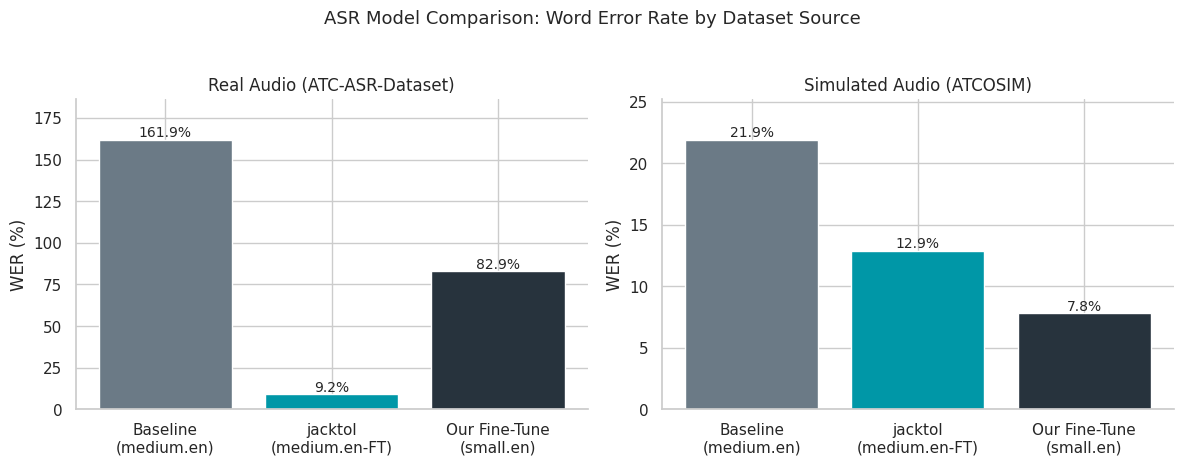

In [39]:
MODEL_ORDER = [BASELINE_MODEL_ID, COMPARISON_MODEL_ID, FINETUNE_MODEL_VERSION]
MODEL_LABELS = {
    BASELINE_MODEL_ID: "Baseline\n(medium.en)",
    COMPARISON_MODEL_ID: "jacktol\n(medium.en-FT)",
    FINETUNE_MODEL_VERSION: "Our Fine-Tune\n(small.en)",
}
MODEL_COLORS = {
    BASELINE_MODEL_ID: "#6B7A86",
    COMPARISON_MODEL_ID: "#0097A7",
    FINETUNE_MODEL_VERSION: "#27333D",
}
SOURCE_PANELS = [
    ("atc-asr-dataset", "Real Audio (ATC-ASR-Dataset)"),
    ("atcosim", "Simulated Audio (ATCOSIM)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (source, title) in zip(axes, SOURCE_PANELS):
    sub = (
        combined_summary[combined_summary["dataset_source"] == source]
        .set_index("model_version")
        .loc[MODEL_ORDER]
    )
    wer_pct = sub["wer"] * 100
    bars = ax.bar(
        [MODEL_LABELS[m] for m in MODEL_ORDER], wer_pct,
        color=[MODEL_COLORS[m] for m in MODEL_ORDER],
    )
    for bar, val in zip(bars, wer_pct):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10,
        )
    ax.set_title(title)
    ax.set_ylabel("WER (%)")
    ax.set_ylim(0, wer_pct.max() * 1.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("ASR Model Comparison: Word Error Rate by Dataset Source", y=1.03, fontsize=13)
fig.tight_layout()
save_fig(fig, "asr_model_comparison_wer")
plt.show()

**Observation:** We can see that with just 3 epochs on a small subset of the training data (1000 samples), we were able to improve the ASR performance with the small whisper model and surpass the ASR performance of the baseline medium whisper model, despite the small whisper model being a quarter of the size. However, it does **not** generalize to real audio anywhere near as well as jacktol's medium-sized fine-tuned whisper model (~83% vs. 9.2% WER). This is expected since the gap in model size and training data volume. On the other hand, the fine-tuned small whisper model does do better than jacktol's model on ATCOSIM (~7.5% vs. 12.9%). However, this isn't an apples-to-apples comparison. jacktol's model never saw ATCOSIM, while the fine-tuned small whisper model's stratified training subset *did* include ATCOSIM samples.

> **NOTE:** training re-runs introduce slight GPU non-determinism and the exact WER shifts by a few tenths of a point each time it's retrained, even with fixed seeds. jacktol's and the baseline's numbers come from fixed, pre-trained checkpoints doing pure inference, so those stay exactly the same run to run.

## D. Aviation-Specific Evaluation

> **NOTE:** neither corpus provides entity spans ground truth data so there's no labeled callsigns, commands, altitudes, etc. We'll have to rely on hardcoded callsign vocabulary for now until we can get such a ground truth dataset.

In [40]:
_CALLSIGN_VOCAB = ICAO_PHONETIC_ALPHABET | KNOWN_CALLSIGN_WORDS

print(f'Total words in callsign vocabulary: {len(_CALLSIGN_VOCAB)}')
print('='*60)
print(_CALLSIGN_VOCAB)

Total words in callsign vocabulary: 42
frozenset({'sierra', 'delta', 'foxtrot', 'charlie', 'swissair', 'whiskey', 'golf', 'india', 'juliet', 'britishairways', 'belair', 'kilo', 'november', 'luxair', 'speedbird', 'zulu', 'yankee', 'xray', 'shamrock', 'hansa', 'tango', 'bravo', 'csa', 'twinstar', 'alpha', 'juliett', 'quebec', 'victor', 'airfrance', 'echo', 'alitalia', 'lufthansa', 'sabena', 'romeo', 'mike', 'crossair', 'oscar', 'papa', 'klm', 'lima', 'hotel', 'uniform'})


In [41]:
print(f'Total words in numeric vocabulary: {len(ATC_NUMERAL_WORDS)}')
print('='*60)
print(ATC_NUMERAL_WORDS)

Total words in numeric vocabulary: 12
frozenset({'niner', 'four', 'seven', 'six', 'nine', 'two', 'one', 'tree', 'zero', 'three', 'five', 'eight'})


In [42]:
print(f'Total words in command vocabulary: {len(ATC_COMMAND_VERBS)}')
print('='*60)
print(ATC_COMMAND_VERBS)

Total words in command vocabulary: 19
frozenset({'expect', 'hold', 'contact', 'established', 'cleared', 'standby', 'climb', 'cross', 'proceed', 'depart', 'report', 'taxi', 'resume', 'descend', 'identified', 'squawk', 'turn', 'land', 'maintain'})


In [43]:
def token_recall(reference_norm: str, hypothesis_norm: str, vocab: frozenset):
    """Fraction of reference tokens in `vocab` that also appear in the
    hypothesis (bag-of-words recall, order-insensitive, proxy only).
    Returns None if the reference has zero matching tokens (the metric is
    undefined, not zero -- avoids silently penalizing utterances with
    nothing to find)."""
    ref_hits = [t for t in reference_norm.split() if t in vocab]
    if not ref_hits:
        return None
    hyp_tokens = set(hypothesis_norm.split())
    return sum(1 for t in ref_hits if t in hyp_tokens) / len(ref_hits)

combined_results["callsign_recall"] = combined_results.apply(
    lambda r: token_recall(r["reference_norm"], r["hypothesis_norm"], _CALLSIGN_VOCAB), axis=1)
combined_results["numeric_recall"] = combined_results.apply(
    lambda r: token_recall(r["reference_norm"], r["hypothesis_norm"], ATC_NUMERAL_WORDS), axis=1)
combined_results["command_recall"] = combined_results.apply(
    lambda r: token_recall(r["reference_norm"], r["hypothesis_norm"], ATC_COMMAND_VERBS), axis=1)

combined_results[["callsign_recall", "numeric_recall", "command_recall"]].describe()

,callsign_recall,numeric_recall,command_recall
count,135.000000,270.000000,201.000000
mean,0.702222,0.927716,0.890547
std,0.436958,0.204406,0.292336
min,0.000000,0.000000,0.000000
25%,0.100000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


### Altitude / Heading / Runway / Frequency Accuracy

As mentioned previously, there's no ground truth data available for altitude, heading, runway, frequency, ect., so we'll have to take a pure rule-based regex approach for now.

In [44]:
_NUM_ALT = "one|two|three|four|five|six|seven|eight|nine|niner|zero"
_NUM = rf"(?:{_NUM_ALT})"

AVIATION_PATTERNS = {
    "frequency": re.compile(rf"\b{_NUM}(?: {_NUM}){{2,}}(?: decimal(?: {_NUM}){{1,3}})\b"),
    "runway": re.compile(rf"\brunway {_NUM}(?: {_NUM})?(?: left| right| center)?\b"),
    "heading": re.compile(rf"\bheading(?: {_NUM}){{3}}\b"),
    "altitude": re.compile(
        rf"\b(?:climb|descend|maintain)(?: to)?(?: (?:{_NUM_ALT}|flight|level|hundred|thousand))+\b"
    ),
}


def pattern_match_recall(reference_norm: str, hypothesis_norm: str, pattern: re.Pattern):
    """Presence proxy: does `pattern` (which fired on the reference) also
    fire somewhere in the hypothesis? None if the pattern never fired on the
    reference (nothing to check), matching `token_recall`'s convention."""
    if not pattern.search(reference_norm):
        return None
    return float(bool(pattern.search(hypothesis_norm)))


for name, pattern in AVIATION_PATTERNS.items():
    combined_results[f"{name}_present_recall"] = combined_results.apply(
        lambda r: pattern_match_recall(r["reference_norm"], r["hypothesis_norm"], pattern), axis=1)

combined_results[[f"{n}_present_recall" for n in AVIATION_PATTERNS]].describe()

,frequency_present_recall,runway_present_recall,heading_present_recall,altitude_present_recall
count,18.000000,30.000000,12.000000,66.000000
mean,0.888889,0.666667,0.916667,0.893939
std,0.323381,0.479463,0.288675,0.310275
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [45]:
proxy_cols = [
    "callsign_recall", "numeric_recall", "command_recall",
    "frequency_present_recall", "runway_present_recall",
    "heading_present_recall", "altitude_present_recall",
]
combined_results.groupby(["model_version", "dataset_source"])[proxy_cols].mean()

callsign_recall  \
model_version                                dataset_source                     
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset         0.970588   
                                             atcosim                 0.860714   
openai/whisper-medium.en                     atc-asr-dataset         0.103922   
                                             atcosim                 0.678571   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset         0.572549   
                                             atcosim                 0.846429   

                                                              numeric_recall  \
model_version                                dataset_source                    
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset        0.953063   
                                             atcosim                1.000000   
openai/whisper-medium.en                     atc-asr-dataset        0.698871   
                                             atcosim                0.971989   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset        0.884269   
                                             atcosim                1.000000   

                                                              command_recall  \
model_version                                dataset_source                    
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset        0.975000   
                                             atcosim                1.000000   
openai/whisper-medium.en                     atc-asr-dataset        0.500000   
                                             atcosim                0.914894   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset        0.625000   
                                             atcosim                1.000000   

                                                              frequency_present_recall  \
model_version                                dataset_source                              
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset                       1.0   
                                             atcosim                               1.0   
openai/whisper-medium.en                     atc-asr-dataset                       0.0   
                                             atcosim                               0.8   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset                       1.0   
                                             atcosim                               1.0   

                                                              runway_present_recall  \
model_version                                dataset_source                           
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset                    0.9   
                                             atcosim                            NaN   
openai/whisper-medium.en                     atc-asr-dataset                    0.6   
                                             atcosim                            NaN   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset                    0.5   
                                             atcosim                            NaN   

                                                              heading_present_recall  \
model_version                                dataset_source                            
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset                     1.0   
                                             atcosim                             1.0   
openai/whisper-medium.en                     atc-asr-dataset                     1.0   
                                             atcosim                             1.0   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset                     0.0   
                                             atcosim                             1.0   

        

### WER vs. Utterance Characteristics

Join eval results back to `utterance_df` by `utterance_id` to relate WER to acoustic/linguistic characteristics (addressing Research Question 3). 

> **NOTE:** `speech_rate_wpm` is unreliable under ~1 second of audio (e.g., dividing by a small denominator), so we masked it to `NaN` below that threshold. This is why we're seeing NaN values for `runway_present_recall` on the ATCOSIM dataset.

Saved figure: ../res/figures/wer_vs_utterance_characteristics.png


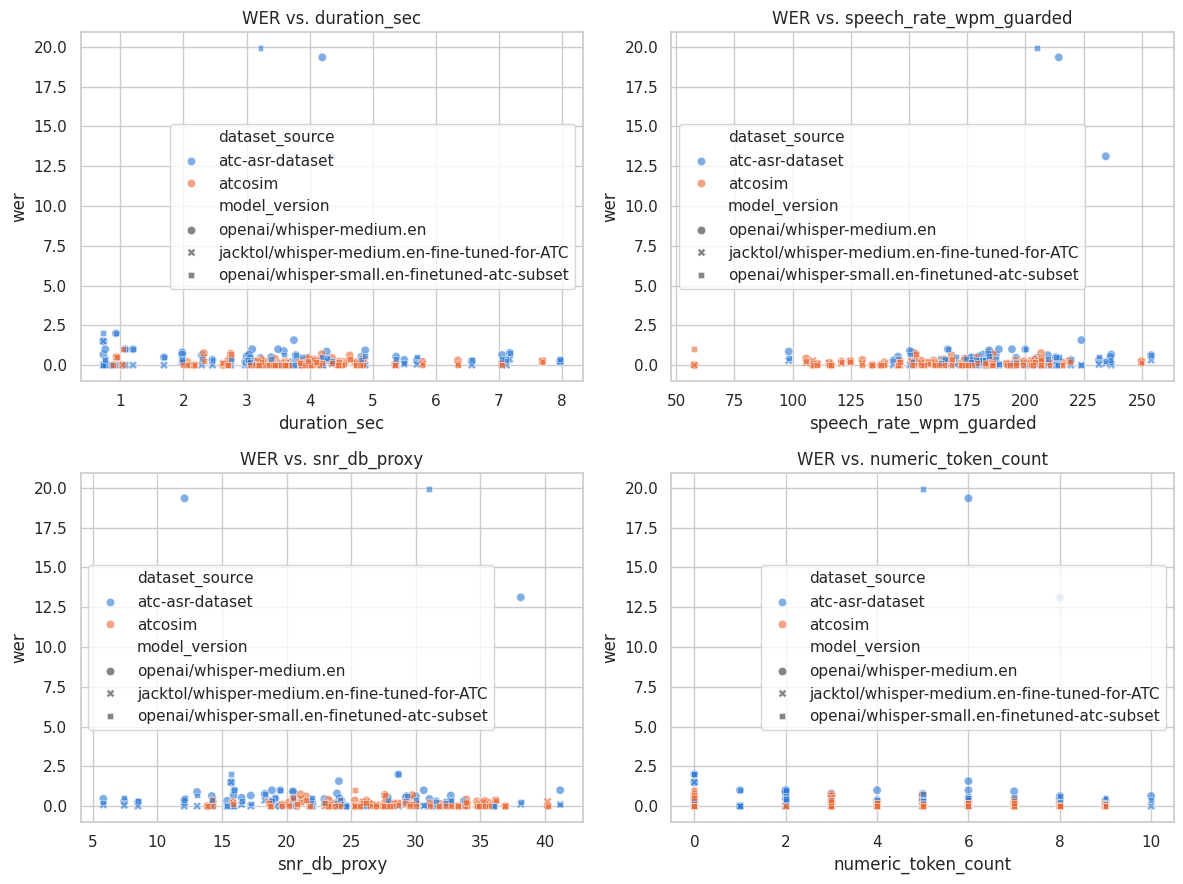

In [46]:
analysis_df = combined_results.merge(
    utterance_df[["utterance_id", "duration_sec", "speech_rate_wpm", "snr_db_proxy", "numeric_token_count"]],
    on="utterance_id", how="left",
)
analysis_df["speech_rate_wpm_guarded"] = analysis_df["speech_rate_wpm"].where(analysis_df["duration_sec"] >= 1.0)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flat, ["duration_sec", "speech_rate_wpm_guarded", "snr_db_proxy", "numeric_token_count"]):
    sns.scatterplot(
        data=analysis_df, x=col, y="wer", hue="dataset_source", hue_order=HUE_ORDER,
        palette=PALETTE, style="model_version", alpha=0.6, ax=ax,
    )
    ax.set_title(f"WER vs. {col}")
fig.tight_layout()
save_fig(fig, "wer_vs_utterance_characteristics")
plt.show()

### Does Lower WER Mean Better Aviation-Entity Recognition?

Word-level WER treats every token equally, but a single missed callsign or altitude digit matters far more operationally than a missed filler word. This checks whether low-WER utterances also score high on the proxy aviation-entity recall metrics, or whether there are counterexamples.

Saved figure: ../res/figures/wer_vs_callsign_recall.png


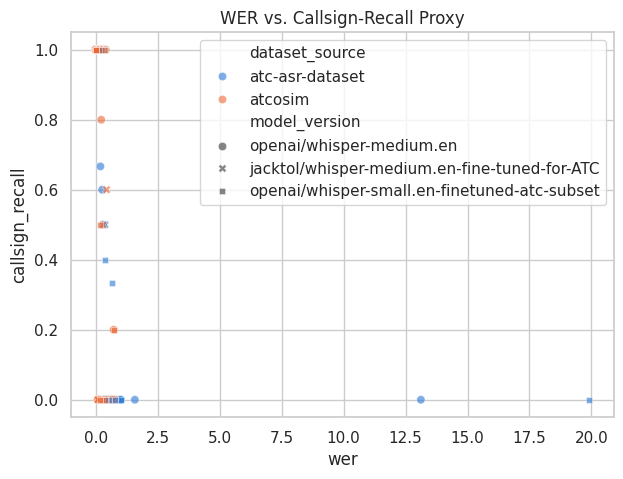

wer  \
model_version                                                            
jacktol/whisper-medium.en-fine-tuned-for-ATC wer              1.000000   
                                             callsign_recall -0.446433   
                                             numeric_recall  -0.147472   
                                             command_recall  -0.004637   
openai/whisper-medium.en                     wer              1.000000   
                                             callsign_recall -0.250083   
                                             numeric_recall  -0.459306   
                                             command_recall  -0.400473   
openai/whisper-small.en-finetuned-atc-subset wer              1.000000   
                                             callsign_recall -0.330251   
                                             numeric_recall  -0.492854   
                                             command_recall  -0.033640   

                                                              callsign_recall  \
model_version                                                                   
jacktol/whisper-medium.en-fine-tuned-for-ATC wer                    -0.446433   
                                             callsign_recall         1.000000   
                                             numeric_recall         -0.124760   
                                             command_recall         -0.074720   
openai/whisper-medium.en                     wer                    -0.250083   
                                             callsign_recall         1.000000   
                                             numeric_recall          0.449816   
                                             command_recall          0.040331   
openai/whisper-small.en-finetuned-atc-subset wer                    -0.330251   
                                             callsign_recall         1.000000   
                                             numeric_recall          0.398451   
                                             command_recall          0.196466   

                                                              numeric_recall  \
model_version                                                                  
jacktol/whisper-medium.en-fine-tuned-for-ATC wer                   -0.147472   
                                             callsign_recall       -0.124760   
                                             numeric_recall         1.000000   
                                             command_recall         0.303274   
openai/whisper-medium.en                     wer                   -0.459306   
                                             callsign_recall        0.449816   
                                             numeric_recall         1.000000   
                                             command_recall         0.280889   
openai/whisper-small.en-finetuned-atc-subset wer                   -0.492854   
                                             callsign_recall        0.398451   
                                             numeric_recall         1.000000   
                                             command_recall         0.356781   

                                                              command_recall  
model_version                                                                 
jacktol/whisper-medium.en-fine-tuned-for-ATC wer                   -0.004637  
                                             callsign_recall       -0.074720  
                                             numeric_recall         0.303274  
                                             command_recall         1.000000  
openai/whisper-medium.en                     wer                   -0.400473  
                                             callsign_recall        0.040331  
                                             numeric_recall         0.280889  
                                             command_recall    

In [47]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=analysis_df, x="wer", y="callsign_recall", hue="dataset_source", hue_order=HUE_ORDER,
    palette=PALETTE, style="model_version", alpha=0.6, ax=ax,
)
ax.set_title("WER vs. Callsign-Recall Proxy")
save_fig(fig, "wer_vs_callsign_recall")
plt.show()

analysis_df.groupby("model_version")[["wer", "callsign_recall", "numeric_recall", "command_recall"]].corr()

**Observation:** The WER vs. recall correlations are moderate and mostly negative. For `openai/whisper-medium.en`, corr(wer, callsign_recall) = -0.25, corr(wer, numeric_recall) = -0.46, and corr(wer, command_recall) = -0.40; for `jacktol/whisper-medium.en-fine-tuned-for-ATC`, corr(wer, callsign_recall) = -0.45; for our own fine-tuned `openai/whisper-small.en`, corr(wer, callsign_recall) ≈ -0.34, corr(wer, numeric_recall) ≈ -0.50, and corr(wer, command_recall) ≈ -0.04 (essentially no relationship). This tells us that the WER signal is not complete. For example, two utterances can have nearly the same WER but differ significantly in whether a specific callsign was correctly recognized or not. Our fine-tune's near-zero command_recall correlation is a good illustration of this: its overall WER barely moves with whether a command verb survives, so a report that only tracked aggregate WER could easily miss that its command recognition is meaningfully worse than its WER alone would suggest.

Introducing this domain gap makes this really clear when we look at the source breakdown. The baseline whisper-medium model's `callsign_recall` drops from **67.9%** on ATCOSIM to just **10.4%** on real ATC-ASR-Dataset audio. This is a much bigger collapse than the aggregate WER numbers (22% -> 162%) would suggest. The `jacktol` fine-tuned/domain-adapted whisper-medium comparison model holds up a lot better across sources (**86.1%** ATCOSIM vs. **97.1%** ATC-ASR-Dataset, but there could be a training data leakage problem with the dataset it used for training). Our own fine-tuned `whisper-small.en` lands in between the two: callsign_recall drops from **~87%** on ATCOSIM to **~57%** on real audio, roughly half the baseline's collapse but still a real domain gap, consistent with training on far less data than jacktol's checkpoint.

## Error Taxonomy
We need to justify the high corpus-level WER. To do so, we'll inspect the worst WER samples and inspect what's really going on.

In [48]:
def describe_alignment(reference_norm: str, hypothesis_norm: str):
    """Word-level alignment for one utterance, resolved to actual
    ref/hyp word spans (jiwer.process_words's own .substitutions/.deletions/
    .insertions are integer counts, not the words themselves -- the words
    live in .alignments, resolved here against .references/.hypotheses)."""
    result = jiwer.process_words(reference_norm, hypothesis_norm)
    ref_words, hyp_words = result.references[0], result.hypotheses[0]
    subs, dels, ins = [], [], []
    for chunk in result.alignments[0]:
        if chunk.type == "substitute":
            subs.append((ref_words[chunk.ref_start_idx:chunk.ref_end_idx],
                         hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx]))
        elif chunk.type == "delete":
            dels.append(ref_words[chunk.ref_start_idx:chunk.ref_end_idx])
        elif chunk.type == "insert":
            ins.append(hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx])
    return subs, dels, ins


worst_rows = (
    combined_results.sort_values("wer", ascending=False)
    .groupby("model_version")
    .head(10)
)
for _, row in worst_rows.iterrows():
    subs, dels, ins = describe_alignment(row["reference_norm"], row["hypothesis_norm"])
    print(f"{row['model_version']} | {row['utterance_id']} | wer={row['wer']:.2f}")
    print(" ref:", row["reference_norm"])
    print(" hyp:", row["hypothesis_norm"])
    print(" substitutions:", subs)
    print(" deletions:", dels)
    print(" insertions:", ins)
    print()

openai/whisper-small.en-finetuned-atc-subset | atc-asr-dataset-test-000445 | wer=19.91
 ref: cleared to land runway three one swiss one two four bravo
 hyp: praha cleared to land runway three run to flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight fli

**Observation:** We can see now that the corpus-level aggregate 162% WER is heavily skewed by two catastrophic outliers (`atc-asr-dataset-test-000294` and `atc-asr-dataset-test-000352`). Both outliers are repetition-loop hallucinations. The *median* per-utterance WER on the real-audio subset is actually 56%, which is still clearly worse than ATCOSIM but far less dramatic than the mean (162%) suggests. This is a good reminder that corpus-level WER can be misleading when a small number of runaway outputs dominate the aggregate mean. This is why the per-utterance error taxonomy is worth looking at alongside the aggregate mean.

The custom fine-tuned `whisper-small.en` shows the identical pattern on the real audio outputs, showing an aggregate WER of ~83% versus a *median* of only ~35%. The aggregate WER is driven by a single repetition-loop outlier (see `atc-asr-dataset-test-000445`, which is just the word "flight" repeated ~215 times). This shows that fine-tuning clearly helped overall accuracy, but there's still the Whisper "bug" that causes repeated classification outputs. This is a known architectural/decoding quirk with Whisper models that fine-tuning won't be able to fix. Thus, we'll have to implement a way to catch and address this classification edge case with Whisper models (e.g., hyperparameter tuning, filtering, etc.). See https://metawhisp.com/blog/whisper-repeating-word-loop-fix/ and https://arxiv.org/pdf/2212.04356

**Taxonomy:**

| Category | Description | Example `utterance_id` |
| --- | --- | --- |
| Repetition-loop hallucination | Whisper's beam search gets stuck repeating a short phrase dozens (or hundreds) of times on short/low-information or noisy audio. This is a known Whisper failure mode that persists even after fine-tuning. Dominates the real-audio aggregate WER for both the baseline and our fine-tune. | `atc-asr-dataset-test-000294` (baseline: "good morning" x~150), `atc-asr-dataset-test-000352` (baseline: "r" x~150), `atc-asr-dataset-test-000445` (our fine-tune: "flight" x~215) |
| Numeral substitution / "nine" vs. "niner" | Caused by the disclosed normalizer gap from Section A: `expand_digits_to_atc_words` always emits "nine", so a reference "niner" mismatches a correct-sounding hypothesis "nine" | `atc-asr-dataset-test-000589` (comparison: ref "niner" -> hyp "nine") |
| Callsign misrecognition | An airline/place-name word substituted for a similar-sounding but wrong one, or (for the smaller fine-tuned model) a phonetic-alphabet callsign garbled into unrelated-sounding words | `atcosim-validation-000979` (baseline: "algerie" -> "jerry"), `atcosim-train-000676` (baseline: "sabena" -> "sabina", "rhein" -> "line"), `atc-asr-dataset-test-000198` (our fine-tune: "eight juliett echo" -> "athria degol") |
| Short-word / sign-off deletion | A trailing acknowledgement or sign-off word dropped entirely | `atcosim-train-003697` (comparison: "tschuss" deleted) |
| Homophone confusion | A word substituted for one that sounds identical or near-identical but changes meaning/spelling | `atcosim-train-000664` (baseline: "rhein" -> "rhine"), `atcosim-train-003601` (baseline: "four" -> "for") |

## Summary

We compared three ASR conditions on the same fixed held-out test split: the generic baseline (`openai/whisper-medium.en`), a domain-adapted comparison model (`jacktol/whisper-medium.en-fine-tuned-for-ATC`), and our own fine-tune (`openai/whisper-small.en-finetuned-atc-subset`). WER was reported both overall and broken down by `dataset_source` (Sections B/C), and all results were saved to `data/processed/asr_results/` as CSV files (`baseline_whisper_medium_en`, `comparison_whisper_medium_en_atc`, `finetuned_whisper_small_en_atc_subset`, `combined_asr_results`, `combined_asr_summary`) so they're not lost when the notebook output is cleared.

Beyond WER, Section D adds aviation-specific proxy metrics -- callsign, numeric, and command recall, plus altitude/heading/runway/frequency presence detection -- along with a WER-vs-entity-recall correlation check to see how well aggregate WER actually tracks the things that matter operationally. Error analysis is covered by the sample review in Sections B/C and the alignment-based error taxonomy above.

For fine-tuning, we went with `openai/whisper-small.en` instead of medium.en to fit within the 8GB VRAM constraint, training on a 1,000-row stratified subset for 3 epochs with `per_device_train_batch_size=4`/`gradient_accumulation_steps=8` (`batch_size=8` caused bad VRAM-pressure slowdown on this GPU). Interestingly, it beat the medium.en baseline in both domains despite having a quarter of the parameters. It doesn't generalize to real audio anywhere near as well as jacktol's model. This is understandable given the difference in model size and training data volume. But it does edge it out on ATCOSIM, albeit not a fair comparison since jacktol's model never saw ATCOSIM while the fine-tuned whisper-small.en model did.

**Known limitations:** the `jacktol` comparison model's numbers on `atc-asr-dataset` carry an unverified train/test-overlap risk; fine-tuned small whisper model's ATCOSIM evaluation results aren't a fair generalization test against jacktol's model for the same reason in reverse (ATCOSIM was in training data for fine-tuning the small whisper model); the aviation-entity metrics are all proxy/heuristic since neither corpus has ground-truth entity spans; the digit-word normalizer still doesn't handle "nine" vs. "niner" or decompose alphanumeric callsigns; and the fine-tuning in this notebook only used 1,000 samples at 3 epochs which is not anywhere close to the full ~13,956 samples in the train split.

**Next steps:** This notebook is intended as a prototype environment to get things working and test things out. The next step is to build a standalone `ASRTrainingPipeline` (and companion `ASREvaluationPipeline`) in `src/` following the same pattern as `DataIngestPipeline`. This will be a self-contained class that can be invoked from the command line without a Jupyter kernel and avoid the memory overhead and output size limitations that come with running full training jobs inside a notebook. Similar to how a YOLO training run works, the pipeline should handle the full loop end-to-end (e.g., loading the preprocessed dataset, fine-tuning, per-epoch checkpoints, and writing evaluation outputs such as per-utterance scores, summary CSVs, figures to a structured `res/` subdirectory so results are organized and reproducible across runs). The inline helper functions and classes defined in this notebook are intended for reuse in the standalone training/evaluation process (e.g., `expand_digits_to_atc_words`, `normalize_for_scoring`, `transcribe_batch`, `token_recall`, etc.).